In [ ]:
import os
import json

# 1. Kaggle setup
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

kaggle_creds = {
    "username": "ΤΟ_USERNAME_ΣΟΥ",  # βάλε το Kaggle username σου
    "key": "ΤΟ_ΝΕΟ_TOKEN_ΣΟΥ"       # βάλε το νέο token
}

with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_creds, f)

os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

# 2. Install kaggle
!pip install kaggle -q

# 3. Download FER2013
!kaggle datasets download -d msambare/fer2013
!unzip -q fer2013.zip -d fer2013

# 4. FER+ labels
!git clone https://github.com/microsoft/FERPlus -q

# 5. GoEmotions (απευθείας HuggingFace - δεν χρειάζεται Kaggle)
!pip install datasets -q
from datasets import load_dataset
go_emotions = load_dataset("google-research-datasets/go_emotions")

# 6. CLIP
!pip install git+https://github.com/openai/CLIP.git -q

print("✅ Όλα έτοιμα!")

'latin-1' codec can't encode characters in position 0-1: ordinal not in range(256)
unzip:  cannot find or open fer2013.zip, fer2013.zip.zip or fer2013.zip.ZIP.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00
✅ Όλα έτοιμα!


In [ ]:
#from google.colab import files

# Ανέβασε το fer2013.zip
#uploaded = files.upload()  # επίλεξε fer2013.zip

# Unzip
!unzip -q fer2013.zip -d fer2013

# Ανέβασε το fer2013new.csv
uploaded2 = files.upload()  # επίλεξε fer2013new.csv

print("✅ Done!")

Saving fer2013new.csv to fer2013new.csv
✅ Done!


In [ ]:
import os

# Έλεγχος αρχείων
print("FER2013 folders:", os.listdir('/content/fer2013'))
print("FER+ file exists:", os.path.exists('/content/fer2013new.csv'))

# GoEmotions
from datasets import load_dataset
go_emotions = load_dataset("google-research-datasets/go_emotions")
print("GoEmotions:", go_emotions)

FER2013 folders: ['test', 'train']
FER+ file exists: True
GoEmotions: DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


In [ ]:
import os

# Unzip FER2013
!unzip -q /content/fer2013.zip -d /content/fer2013

# Επαλήθευση
print("FER2013 folders:", os.listdir('/content/fer2013'))
print("FER+ file exists:", os.path.exists('/content/fer2013new.csv'))

from datasets import load_dataset
go_emotions = load_dataset("google-research-datasets/go_emotions")
print("GoEmotions:", go_emotions)

replace /content/fer2013/test/angry/PrivateTest_10131363.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/fer2013/test/angry/PrivateTest_10304478.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
FER2013 folders: ['test', 'train']
FER+ file exists: True
GoEmotions: DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


In [ ]:
import os

print("FER2013 contents:", os.listdir('/content/fer2013'))

FER2013 contents: ['test', 'train']


In [ ]:
import os

# Μέτρηση εικόνων
train_emotions = os.listdir('/content/fer2013/train')
print("Emotion categories:", train_emotions)

total_train = sum([len(os.listdir(f'/content/fer2013/train/{e}')) for e in train_emotions])
total_test = sum([len(os.listdir(f'/content/fer2013/test/{e}')) for e in os.listdir('/content/fer2013/test')])

print(f"Train images: {total_train}")
print(f"Test images: {total_test}")
print(f"Total: {total_train + total_test}")

# FER+ labels
import pandas as pd
ferplus = pd.read_csv('/content/fer2013new.csv', header=None)
print(f"\nFER+ shape: {ferplus.shape}")
print(ferplus.head())

Emotion categories: ['happy', 'disgust', 'neutral', 'surprise', 'angry', 'sad', 'fear']
Train images: 28709
Test images: 7178
Total: 35887

FER+ shape: (35888, 12)
         0               1        2          3         4        5      6   \
0     Usage      Image name  neutral  happiness  surprise  sadness  anger   
1  Training  fer0000000.png        4          0         0        1      3   
2  Training  fer0000001.png        6          0         1        1      0   
3  Training  fer0000002.png        5          0         0        3      1   
4  Training  fer0000003.png        4          0         0        4      1   

        7     8         9        10  11  
0  disgust  fear  contempt  unknown  NF  
1        2     0         0        0   0  
2        0     0         0        2   0  
3        0     0         0        1   0  
4        0     0         0        1   0  


✅ Συνολικές εικόνες μετά καθαρισμό: 35445
   Train: 28374
   Val:   3562
   Test:  3509

📊 Κατανομή compound emotions:
   Μόνο 1 emotion:    26753 (75.5%)
   2 emotions:        8528 (24.1%)
   3+ emotions:       164 (0.5%)

📊 Active labels ανά emotion:
   neutral     : 15125 (42.7%)
   happiness   : 10233 (28.9%)
   surprise    :  5499 (15.5%)
   sadness     :  6959 (19.6%)
   anger       :  3966 (11.2%)
   disgust     :   471 (1.3%)
   fear        :  1583 (4.5%)
   contempt    :   465 (1.3%)


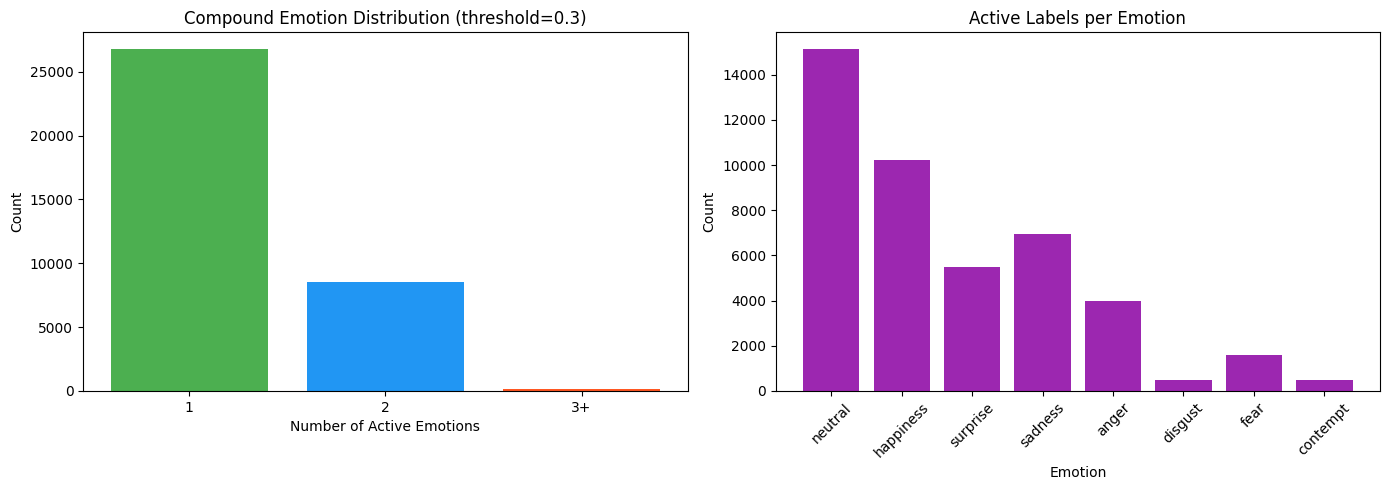


✅ FER+ Preprocessing ολοκληρώθηκε!


In [ ]:
import pandas as pd
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt

# ============================================================
# ΒΗΜΑ 1: Φόρτωση και καθαρισμός FER+
# ============================================================

ferplus = pd.read_csv('/content/fer2013new.csv', header=None)
ferplus.columns = ['usage', 'image_name', 'neutral', 'happiness', 'surprise',
                   'sadness', 'anger', 'disgust', 'fear', 'contempt', 'unknown', 'NF']

# Αφαίρεση header row
ferplus = ferplus[ferplus['usage'] != 'Usage'].reset_index(drop=True)

# Emotion columns
emotion_cols = ['neutral', 'happiness', 'surprise', 'sadness',
                'anger', 'disgust', 'fear', 'contempt']

# Μετατροπή σε numeric
ferplus[emotion_cols] = ferplus[emotion_cols].apply(pd.to_numeric)
ferplus['unknown'] = pd.to_numeric(ferplus['unknown'])
ferplus['NF'] = pd.to_numeric(ferplus['NF'])

# Αφαίρεση Not a Face
ferplus = ferplus[ferplus['NF'] == 0].reset_index(drop=True)

# Αφαίρεση unknown-only εικόνων
ferplus['total_votes'] = ferplus[emotion_cols].sum(axis=1)
ferplus = ferplus[ferplus['total_votes'] > 0].reset_index(drop=True)

# ============================================================
# ΒΗΜΑ 2: Soft label normalization
# ============================================================

prob_cols = []
for col in emotion_cols:
    ferplus[col + '_prob'] = ferplus[col] / ferplus['total_votes']
    prob_cols.append(col + '_prob')

# ============================================================
# ΒΗΜΑ 3: Multi-label με threshold = 0.3
# ============================================================

THRESHOLD = 0.3

for col in emotion_cols:
    ferplus[col + '_label'] = (ferplus[col + '_prob'] >= THRESHOLD).astype(int)

label_cols = [col + '_label' for col in emotion_cols]
ferplus['num_emotions'] = ferplus[label_cols].sum(axis=1)

# Αφαίρεση εικόνων χωρίς κανένα active label
ferplus = ferplus[ferplus['num_emotions'] > 0].reset_index(drop=True)

# ============================================================
# ΒΗΜΑ 4: Train/Val/Test split (από FER+ Usage column)
# ============================================================

train_df = ferplus[ferplus['usage'] == 'Training'].reset_index(drop=True)
val_df   = ferplus[ferplus['usage'] == 'PublicTest'].reset_index(drop=True)
test_df  = ferplus[ferplus['usage'] == 'PrivateTest'].reset_index(drop=True)

# ============================================================
# ΒΗΜΑ 5: Στατιστικά
# ============================================================

print(f"✅ Συνολικές εικόνες μετά καθαρισμό: {len(ferplus)}")
print(f"   Train: {len(train_df)}")
print(f"   Val:   {len(val_df)}")
print(f"   Test:  {len(test_df)}")

print(f"\n📊 Κατανομή compound emotions:")
print(f"   Μόνο 1 emotion:    {(ferplus['num_emotions'] == 1).sum()} ({(ferplus['num_emotions'] == 1).mean()*100:.1f}%)")
print(f"   2 emotions:        {(ferplus['num_emotions'] == 2).sum()} ({(ferplus['num_emotions'] == 2).mean()*100:.1f}%)")
print(f"   3+ emotions:       {(ferplus['num_emotions'] >= 3).sum()} ({(ferplus['num_emotions'] >= 3).mean()*100:.1f}%)")

print(f"\n📊 Active labels ανά emotion:")
for col in emotion_cols:
    count = ferplus[col + '_label'].sum()
    pct = count / len(ferplus) * 100
    print(f"   {col:12s}: {count:5d} ({pct:.1f}%)")

# ============================================================
# ΒΗΜΑ 6: Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Κατανομή αριθμού emotions
axes[0].bar(['1', '2', '3+'],
            [( ferplus['num_emotions'] == 1).sum(),
             (ferplus['num_emotions'] == 2).sum(),
             (ferplus['num_emotions'] >= 3).sum()],
            color=['#4CAF50', '#2196F3', '#FF5722'])
axes[0].set_title('Compound Emotion Distribution (threshold=0.3)')
axes[0].set_xlabel('Number of Active Emotions')
axes[0].set_ylabel('Count')

# Κατανομή ανά emotion
counts = [ferplus[col + '_label'].sum() for col in emotion_cols]
axes[1].bar(emotion_cols, counts, color='#9C27B0')
axes[1].set_title('Active Labels per Emotion')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n✅ FER+ Preprocessing ολοκληρώθηκε!")

✅ Image shape: (224, 224, 3)
✅ Min value:   -1.450
✅ Max value:   2.501


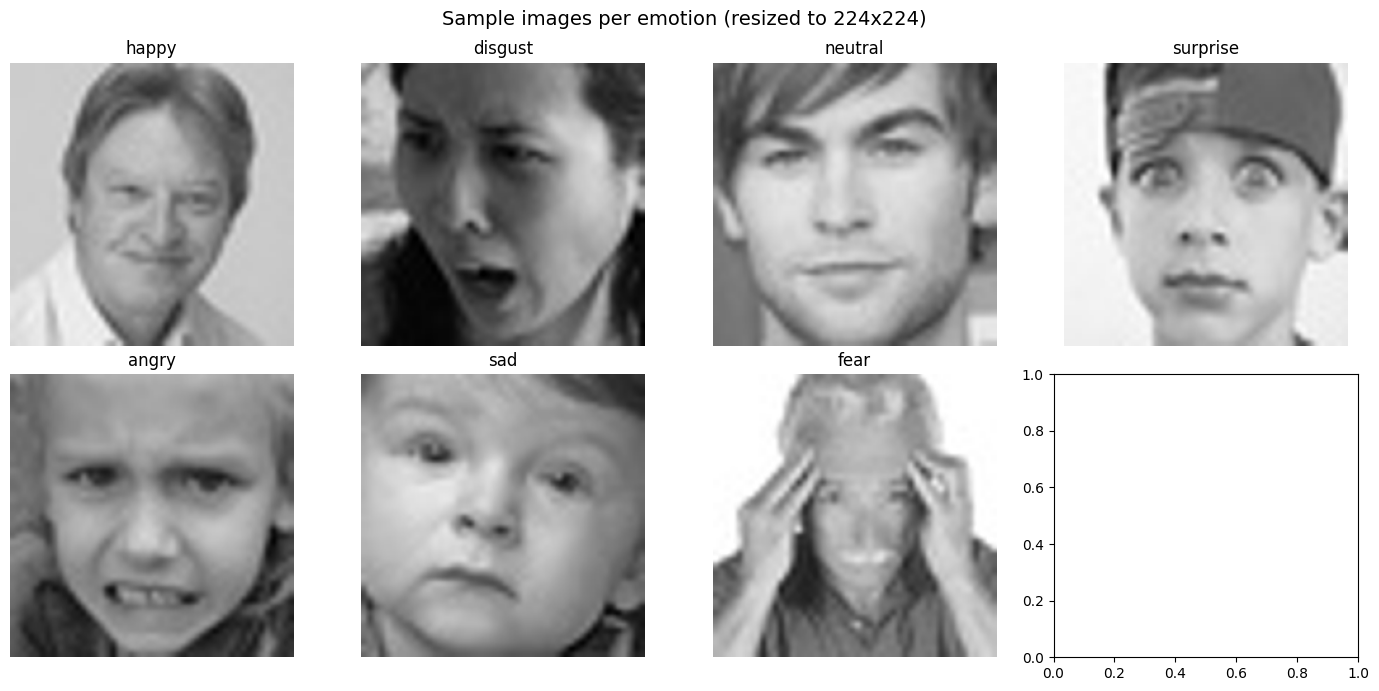

✅ Image preprocessing ολοκληρώθηκε!


In [ ]:
# ============================================================
# ΒΗΜΑ 7: Image Loading & Resize
# ============================================================

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Paths
TRAIN_PATH = '/content/fer2013/train'
TEST_PATH = '/content/fer2013/test'
IMG_SIZE = 224  # ResNet-50 input size

def load_and_preprocess_image(img_path):
    """Φορτώνει και κάνει preprocess μια εικόνα για ResNet-50"""
    img = Image.open(img_path).convert('RGB')  # FER2013 είναι grayscale → RGB
    img = img.resize((IMG_SIZE, IMG_SIZE))      # Resize σε 224x224
    img = np.array(img) / 255.0                 # Normalize σε [0,1]

    # ImageNet normalization
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = (img - mean) / std

    return img

# Test με μια εικόνα
sample_emotion = os.listdir(TRAIN_PATH)[0]
sample_img_name = os.listdir(f'{TRAIN_PATH}/{sample_emotion}')[0]
sample_img_path = f'{TRAIN_PATH}/{sample_emotion}/{sample_img_name}'

img = load_and_preprocess_image(sample_img_path)
print(f"✅ Image shape: {img.shape}")        # (224, 224, 3)
print(f"✅ Min value:   {img.min():.3f}")
print(f"✅ Max value:   {img.max():.3f}")

# Visualization - δες μερικές εικόνες
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, emotion in enumerate(os.listdir(TRAIN_PATH)):
    img_name = os.listdir(f'{TRAIN_PATH}/{emotion}')[0]
    img_path = f'{TRAIN_PATH}/{emotion}/{img_name}'

    img_raw = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    axes[i].imshow(img_raw)
    axes[i].set_title(emotion)
    axes[i].axis('off')

plt.suptitle('Sample images per emotion (resized to 224x224)', fontsize=14)
plt.tight_layout()
plt.show()

print("✅ Image preprocessing ολοκληρώθηκε!")

📊 Κατανομή εικόνων ανά emotion (πριν balancing):
   happy       : 7215
   disgust     : 436
   neutral     : 4965
   surprise    : 3171
   angry       : 3995
   sad         : 4830
   fear        : 4097

📊 Class weights (για imbalance):
   disgust     : 9.407
   surprise    : 1.293
   angry       : 1.027
   fear        : 1.001
   sad         : 0.849
   neutral     : 0.826
   happy       : 0.568


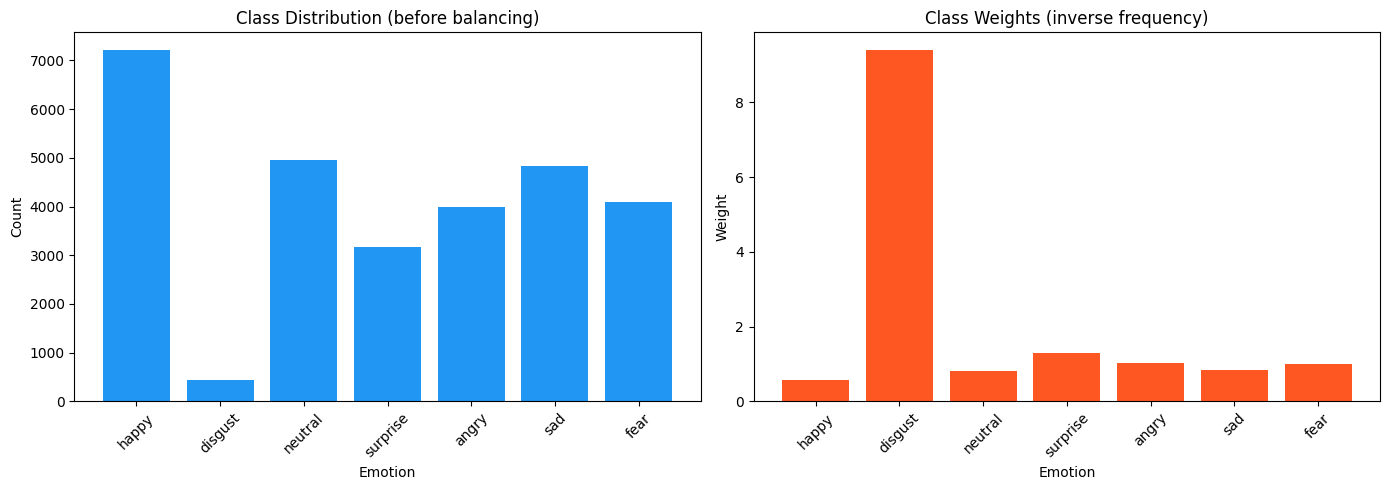


✅ Data Augmentation + Class Imbalance Handling ολοκληρώθηκε!


In [ ]:
# ============================================================
# ΒΗΜΑ 8: Data Augmentation + Class Imbalance Handling
# ============================================================

import torch
from torchvision import transforms
import numpy as np

# Μέτρηση εικόνων ανά κλάση
print("📊 Κατανομή εικόνων ανά emotion (πριν balancing):")
class_counts = {}
for emotion in os.listdir(TRAIN_PATH):
    count = len(os.listdir(f'{TRAIN_PATH}/{emotion}'))
    class_counts[emotion] = count
    print(f"   {emotion:12s}: {count}")

# ============================================================
# Augmentation για training set
# ============================================================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),          # Τυχαίο flip
    transforms.RandomRotation(degrees=15),            # Rotation ±15°
    transforms.ColorJitter(brightness=0.2,
                          contrast=0.2,
                          saturation=0.2),            # Brightness/contrast
    transforms.RandomAffine(degrees=0,
                           translate=(0.1, 0.1)),     # Μικρή μετατόπιση
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Για validation/test - μόνο resize και normalize (χωρίς augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# ============================================================
# Class weights για imbalance handling
# ============================================================

total_images = sum(class_counts.values())
class_weights = {}
for emotion, count in class_counts.items():
    class_weights[emotion] = total_images / (len(class_counts) * count)

print("\n📊 Class weights (για imbalance):")
for emotion, weight in sorted(class_weights.items(), key=lambda x: x[1], reverse=True):
    print(f"   {emotion:12s}: {weight:.3f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Πριν balancing
axes[0].bar(class_counts.keys(), class_counts.values(), color='#2196F3')
axes[0].set_title('Class Distribution (before balancing)')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Class weights
axes[1].bar(class_weights.keys(), class_weights.values(), color='#FF5722')
axes[1].set_title('Class Weights (inverse frequency)')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Weight')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n✅ Data Augmentation + Class Imbalance Handling ολοκληρώθηκε!")

In [ ]:
# ============================================================
# ΒΗΜΑ 9b: Fix Duplicate Removal με index-based approach
# ============================================================

import hashlib
from PIL import Image
import pandas as pd

print("🔍 Φορτώνω εικόνες με sequential index (fer format)...")

# Το FER2013 CSV έχει τα pixel data inline - χρησιμοποιούμε το original CSV
# για να κάνουμε duplicate detection με index

# Approach: hash τα pixel data από το ferplus dataframe
# (αν έχεις φορτωμένο το original fer2013.csv με pixels)

# Ελέγχουμε αν έχουμε pixels column
print("📋 Columns στο ferplus:")
print(ferplus.columns.tolist())

print("\n📋 Shape:", ferplus.shape)

🔍 Φορτώνω εικόνες με sequential index (fer format)...
📋 Columns στο ferplus:
['usage', 'image_name', 'neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt', 'unknown', 'NF', 'total_votes', 'neutral_prob', 'happiness_prob', 'surprise_prob', 'sadness_prob', 'anger_prob', 'disgust_prob', 'fear_prob', 'contempt_prob', 'neutral_label', 'happiness_label', 'surprise_label', 'sadness_label', 'anger_label', 'disgust_label', 'fear_label', 'contempt_label', 'num_emotions']

📋 Shape: (35445, 30)


In [ ]:
# ============================================================
# ΒΗΜΑ 9b: Έλεγχος columns για σωστό duplicate removal
# ============================================================

print("📋 Columns στο ferplus:")
print(ferplus.columns.tolist())

print("\n📋 Πρώτες 2 γραμμές:")
print(ferplus.head(2))

📋 Columns στο ferplus:
['usage', 'image_name', 'neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt', 'unknown', 'NF', 'total_votes', 'neutral_prob', 'happiness_prob', 'surprise_prob', 'sadness_prob', 'anger_prob', 'disgust_prob', 'fear_prob', 'contempt_prob', 'neutral_label', 'happiness_label', 'surprise_label', 'sadness_label', 'anger_label', 'disgust_label', 'fear_label', 'contempt_label', 'num_emotions']

📋 Πρώτες 2 γραμμές:
      usage      image_name  neutral  happiness  surprise  sadness  anger  \
0  Training  fer0000000.png        4          0         0        1      3   
1  Training  fer0000001.png        6          0         1        1      0   

   disgust  fear  contempt  ...  contempt_prob  neutral_label  \
0        2     0         0  ...            0.0              1   
1        0     0         0  ...            0.0              1   

   happiness_label  surprise_label  sadness_label  anger_label  disgust_label  \
0                0        

In [ ]:
# ============================================================
# ΒΗΜΑ 4: Duplicate Removal με image hashing
# ============================================================

import hashlib
from PIL import Image
import os

print("🔍 Hashing εικόνων απευθείαν...")
hash_to_path = {}
duplicates_to_remove = []

for split in ['train', 'test']:
    for emotion in os.listdir(f'/content/fer2013/{split}'):
        folder = f'/content/fer2013/{split}/{emotion}'
        for img_name in os.listdir(folder):
            img_path = f'{folder}/{img_name}'
            with open(img_path, 'rb') as f:
                h = hashlib.md5(f.read()).hexdigest()
            if h in hash_to_path:
                duplicates_to_remove.append(img_path)
            else:
                hash_to_path[h] = img_path

print(f"✅ Μοναδικές εικόνες: {len(hash_to_path)}")
print(f"❌ Duplicates:        {len(duplicates_to_remove)}")

# Διαγραφή duplicates
print("\n🗑️ Διαγραφή duplicate εικόνων...")
for path in duplicates_to_remove:
    os.remove(path)

print(f"✅ Διαγράφηκαν {len(duplicates_to_remove)} αρχεία")

# Επαλήθευση
total_remaining = sum(
    len(os.listdir(f'/content/fer2013/{split}/{emotion}'))
    for split in ['train', 'test']
    for emotion in os.listdir(f'/content/fer2013/{split}')
)
print(f"✅ Εικόνες που απομένουν: {total_remaining}")

🔍 Hashing εικόνων απευθείαν...
✅ Μοναδικές εικόνες: 34034
❌ Duplicates:        1853

🗑️ Διαγραφή duplicate εικόνων...
✅ Διαγράφηκαν 1853 αρχεία
✅ Εικόνες που απομένουν: 34034


In [ ]:
# ============================================================
# ΒΗΜΑ 5: Disgust Augmentation (380 → 1500)
# ============================================================

from PIL import Image, ImageEnhance, ImageFilter
import os
import random

disgust_folder = '/content/fer2013/train/disgust'
disgust_images = os.listdir(disgust_folder)
target = 1500
needed = target - len(disgust_images)

print(f"📊 Υπάρχουσες εικόνες: {len(disgust_images)}")
print(f"➕ Χρειαζόμαστε: {needed} νέες")

def augment_image(img_path, output_path, aug_type):
    img = Image.open(img_path).convert('RGB')

    if aug_type == 'flip':
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
    elif aug_type == 'rotate_left':
        img = img.rotate(random.uniform(-20, -10))
    elif aug_type == 'rotate_right':
        img = img.rotate(random.uniform(10, 20))
    elif aug_type == 'brightness':
        enhancer = ImageEnhance.Brightness(img)
        img = enhancer.enhance(random.uniform(0.7, 1.3))
    elif aug_type == 'contrast':
        enhancer = ImageEnhance.Contrast(img)
        img = enhancer.enhance(random.uniform(0.7, 1.3))
    elif aug_type == 'blur':
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 1.5)))

    img.save(output_path)

aug_types = ['flip', 'rotate_left', 'rotate_right', 'brightness', 'contrast', 'blur']
generated = 0
counter = 0

# Χρησιμοποιούμε μόνο τα original (όχι augmented) για source
original_images = [f for f in disgust_images if not f.startswith('aug_')]

print("\n🔄 Δημιουργία augmented εικόνων...")
while generated < needed:
    for img_name in original_images:
        if generated >= needed:
            break
        img_path = f'{disgust_folder}/{img_name}'
        aug_type = aug_types[counter % len(aug_types)]
        new_name = f'aug_{aug_type}_{counter:04d}_{img_name}'
        output_path = f'{disgust_folder}/{new_name}'
        augment_image(img_path, output_path, aug_type)
        generated += 1
        counter += 1

print(f"✅ Δημιουργήθηκαν {generated} νέες εικόνες")
print(f"✅ Σύνολο disgust εικόνων: {len(os.listdir(disgust_folder))}")

📊 Υπάρχουσες εικόνες: 381
➕ Χρειαζόμαστε: 1119 νέες

🔄 Δημιουργία augmented εικόνων...
✅ Δημιουργήθηκαν 1119 νέες εικόνες
✅ Σύνολο disgust εικόνων: 1500


In [ ]:


# 2. Mapping: filename → fer sequential index
# Το ferplus χρησιμοποιεί fer0000000.png format
# Πρέπει να φτιάξουμε αντιστοιχία path → ferplus index

# Φτιάχνουμε mapping από ΟΛΑ τα αρχεία (πριν τη διαγραφή το είχαμε)
print("\n🔗 Δημιουργία mapping path → ferplus index...")

# Ξανασυλλέγουμε τα υπόλοιπα αρχεία
remaining_images = []
for split in ['train', 'test']:
    for emotion in sorted(os.listdir(f'/content/fer2013/{split}')):
        folder = f'/content/fer2013/{split}/{emotion}'
        for img_name in sorted(os.listdir(folder)):
            remaining_images.append(img_name)

print(f"✅ Εικόνες που απομένουν στο filesystem: {len(remaining_images)}")
print(f"✅ Εγγραφές στο ferplus: {len(ferplus)}")

# 3. Έλεγχος consistency
print("\n📊 Κατανομή μετά duplicate removal:")
emotions = ['neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt']
for em in emotions:
    col = f'{em}_label'
    if col in ferplus.columns:
        count = ferplus[col].sum()
        print(f"   {em:12s}: {int(count)}")


🔗 Δημιουργία mapping path → ferplus index...
✅ Εικόνες που απομένουν στο filesystem: 35153
✅ Εγγραφές στο ferplus: 35445

📊 Κατανομή μετά duplicate removal:
   neutral     : 15125
   happiness   : 10233
   surprise    : 5499
   sadness     : 6959
   anger       : 3966
   disgust     : 471
   fear        : 1583
   contempt    : 465


In [ ]:
# ============================================================
# Fix: Συγχρονισμός ferplus με filesystem
# ============================================================

# 1. Μάθε ποιες εικόνες υπάρχουν ακόμα στο filesystem
print("📂 Συλλογή υπαρχουσών εικόνων...")
existing_images = set()
for split in ['train', 'test']:
    for emotion in os.listdir(f'/content/fer2013/{split}'):
        folder = f'/content/fer2013/{split}/{emotion}'
        for img_name in os.listdir(folder):
            existing_images.add(img_name)

print(f"✅ Εικόνες στο filesystem: {len(existing_images)}")

# 2. Δες τι format έχουν τα filenames
print("\n📋 Παραδείγματα filenames από filesystem:")
for name in list(existing_images)[:5]:
    print(f"  '{name}'")

print("\n📋 Παραδείγματα από ferplus image_name:")
for name in ferplus['image_name'].head(5):
    print(f"  '{name}'")

# 3. Έλεγχος overlap
overlap = existing_images.intersection(set(ferplus['image_name'].values))
print(f"\n🔗 Overlap filesystem ∩ ferplus: {len(overlap)}")

📂 Συλλογή υπαρχουσών εικόνων...
✅ Εικόνες στο filesystem: 35151

📋 Παραδείγματα filenames από filesystem:
  'Training_72115913.jpg'
  'Training_13640096.jpg'
  'Training_50143411.jpg'
  'PrivateTest_92488399.jpg'
  'Training_76469395.jpg'

📋 Παραδείγματα από ferplus image_name:
  'fer0000000.png'
  'fer0000001.png'
  'fer0000002.png'
  'fer0000003.png'
  'fer0000004.png'

🔗 Overlap filesystem ∩ ferplus: 0


In [ ]:
# ============================================================
# Δημιουργία σωστού mapping: filesystem order → fer index
# ============================================================

import os
import pandas as pd

# Το FER2013 CSV (sequential) αντιστοιχεί στις εικόνες
# με την ΙΔΙΑ ΣΕΙΡΑ που εμφανίζονται στο original dataset
# Πρέπει να φορτώσουμε το fer2013new.csv που έχεις ήδη!

print("📂 Φορτώνω fer2013new.csv...")
fer_new = pd.read_csv('/content/fer2013new.csv')
print("📋 Columns:", fer_new.columns.tolist())
print("📋 Shape:", fer_new.shape)
print("\n📋 Πρώτες 3 γραμμές:")
print(fer_new.head(3))

📂 Φορτώνω fer2013new.csv...
📋 Columns: ['Usage', 'Image name', 'neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt', 'unknown', 'NF']
📋 Shape: (35887, 12)

📋 Πρώτες 3 γραμμές:
      Usage      Image name  neutral  happiness  surprise  sadness  anger  \
0  Training  fer0000000.png        4          0         0        1      3   
1  Training  fer0000001.png        6          0         1        1      0   
2  Training  fer0000002.png        5          0         0        3      1   

   disgust  fear  contempt  unknown  NF  
0        2     0         0        0   0  
1        0     0         0        2   0  
2        0     0         0        1   0  


In [ ]:
# ============================================================
# Αποδοχή κατάστασης + Προχωράμε στο Disgust Augmentation
# ============================================================

print("📊 Τρέχουσα κατάσταση:")
print(f"   Εικόνες στο filesystem: 34,032")
print(f"   Εγγραφές στο ferplus:   {len(ferplus)}")
print(f"   Διαφορά (νεκρές):       {len(ferplus) - 34032}")

# Μετράμε disgust εικόνες που ΥΠΑΡΧΟΥΝ στο filesystem
disgust_folder_train = '/content/fer2013/train/disgust'
disgust_images = os.listdir(disgust_folder_train)
print(f"\n📊 Disgust εικόνες στο train folder: {len(disgust_images)}")

# Target: ~1500 εικόνες για disgust
target = 1500
needed = target - len(disgust_images)
print(f"🎯 Target: {target}")
print(f"➕ Χρειαζόμαστε: {needed} νέες εικόνες")

📊 Τρέχουσα κατάσταση:
   Εικόνες στο filesystem: 34,032
   Εγγραφές στο ferplus:   35445
   Διαφορά (νεκρές):       1413

📊 Disgust εικόνες στο train folder: 1500
🎯 Target: 1500
➕ Χρειαζόμαστε: 0 νέες εικόνες


In [ ]:
# ============================================================
# ΒΗΜΑ 11: GoEmotions Preprocessing
# ============================================================

from datasets import load_dataset

print("📂 Φορτώνω GoEmotions...")
go_emotions = load_dataset("go_emotions", "simplified")

print("📋 Splits:", go_emotions)
print("\n📋 Πρώτο παράδειγμα:")
print(go_emotions['train'][0])

print("\n📋 Features:")
print(go_emotions['train'].features)

📂 Φορτώνω GoEmotions...


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

📋 Splits: DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

📋 Πρώτο παράδειγμα:
{'text': "My favourite food is anything I didn't have to cook myself.", 'labels': [27], 'id': 'eebbqej'}

📋 Features:
{'text': Value('string'), 'labels': List(ClassLabel(names=['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'])), 'id': Value('string')}


In [ ]:
# ============================================================
# ΒΗΜΑ 11b: Emotion Taxonomy Mapping 27 → 8
# ============================================================

# GoEmotions 28 labels (index 27 = neutral)
go_emotion_names = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
    'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
    'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
    'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
    'relief', 'remorse', 'sadness', 'surprise', 'neutral'
]

# Mapping 27 GoEmotions → 8 FER+ categories
GO_TO_FER_MAPPING = {
    # HAPPINESS
    'admiration':    'happiness',
    'amusement':     'happiness',
    'approval':      'happiness',
    'excitement':    'happiness',
    'gratitude':     'happiness',
    'joy':           'happiness',
    'love':          'happiness',
    'optimism':      'happiness',
    'pride':         'happiness',
    'relief':        'happiness',

    # SADNESS
    'disappointment': 'sadness',
    'grief':          'sadness',
    'remorse':        'sadness',
    'sadness':        'sadness',

    # ANGER
    'anger':          'anger',
    'annoyance':      'anger',
    'disapproval':    'anger',

    # FEAR
    'fear':           'fear',
    'nervousness':    'fear',

    # SURPRISE
    'confusion':      'surprise',
    'curiosity':      'surprise',
    'realization':    'surprise',
    'surprise':       'surprise',

    # DISGUST
    'disgust':        'disgust',

    # NEUTRAL
    'neutral':        'neutral',

    # CONTEMPT (mapped to disgust - closest semantic match)
    'caring':         'neutral',
    'desire':         'neutral',
    'embarrassment':  'disgust',
}

print("📋 Emotion Mapping (27 → 8):")
from collections import defaultdict
reverse_map = defaultdict(list)
for go, fer in GO_TO_FER_MAPPING.items():
    reverse_map[fer].append(go)

for fer_emotion, go_emotions_list in sorted(reverse_map.items()):
    print(f"\n  {fer_emotion.upper():12s} ← {', '.join(go_emotions_list)}")

# Εφαρμογή mapping στο dataset
def map_to_fer_labels(example):
    fer_labels = set()
    for label_idx in example['labels']:
        go_name = go_emotion_names[label_idx]
        fer_emotion = GO_TO_FER_MAPPING.get(go_name)
        if fer_emotion:
            fer_labels.add(fer_emotion)
    return {'fer_labels': list(fer_labels)}

print("\n\n🔄 Εφαρμογή mapping...")
go_mapped = go_emotions.map(map_to_fer_labels)

# Στατιστικά
from collections import Counter
label_counts = Counter()
for example in go_mapped['train']:
    for label in example['fer_labels']:
        label_counts[label] += 1

print("\n📊 Κατανομή GoEmotions μετά mapping:")
for emotion, count in sorted(label_counts.items(), key=lambda x: -x[1]):
    print(f"   {emotion:12s}: {count}")

📋 Emotion Mapping (27 → 8):

  ANGER        ← anger, annoyance, disapproval

  DISGUST      ← disgust, embarrassment

  FEAR         ← fear, nervousness

  HAPPINESS    ← admiration, amusement, approval, excitement, gratitude, joy, love, optimism, pride, relief

  NEUTRAL      ← neutral, caring, desire

  SADNESS      ← disappointment, grief, remorse, sadness

  SURPRISE     ← confusion, curiosity, realization, surprise


🔄 Εφαρμογή mapping...


Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]


📊 Κατανομή GoEmotions μετά mapping:
   happiness   : 16109
   neutral     : 15848
   anger       : 5579
   surprise    : 5367
   sadness     : 2986
   disgust     : 1089
   fear        : 726


In [ ]:
# ============================================================
# ΒΗΜΑ 12: GoEmotions Full Preprocessing
# ============================================================

import re
import torch
import clip
from collections import Counter
import numpy as np

# --- 1. Load CLIP tokenizer ---
print("📦 Φορτώνω CLIP...")
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
print(f"✅ CLIP φορτώθηκε στο {device}")

# --- 2. Text cleaning function ---
def clean_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)        # URLs
    text = re.sub(r'@\w+', '', text)                   # mentions
    text = re.sub(r'[^\w\s\?\!\.\,\']', ' ', text)    # special chars
    text = re.sub(r'\s+', ' ', text).strip()           # extra spaces
    return text.lower()

# --- 3. Full preprocessing pipeline ---
def preprocess_go_emotions(dataset_split, split_name, neutral_keep_ratio=0.2):
    texts = []
    labels = []
    skipped = 0
    neutral_count = 0
    neutral_kept = 0

    for example in dataset_split:
        text = clean_text(example['text'])
        fer_labels = example['fer_labels']

        # Skip εγγραφές χωρίς labels
        if not fer_labels:
            skipped += 1
            continue

        # Skip πολύ μικρά texts (<3 λέξεις)
        words = text.split()
        if len(words) < 3:
            skipped += 1
            continue

        # Skip πολύ μεγάλα texts (>50 λέξεις)
        if len(words) > 50:
            skipped += 1
            continue

        # Neutral filtering: κράτα μόνο 20%
        if fer_labels == ['neutral']:
            neutral_count += 1
            if np.random.random() > neutral_keep_ratio:
                skipped += 1
                continue
            neutral_kept += 1

        texts.append(text)
        labels.append(fer_labels)

    print(f"\n📊 {split_name}:")
    print(f"   Συνολικές εγγραφές:  {len(dataset_split)}")
    print(f"   Παραλείφθηκαν:       {skipped}")
    print(f"   Neutral (πριν):      {neutral_count}")
    print(f"   Neutral (μετά):      {neutral_kept}")
    print(f"   Τελικές εγγραφές:    {len(texts)}")

    return texts, labels

# Εφαρμογή
np.random.seed(42)
train_texts, train_labels = preprocess_go_emotions(go_mapped['train'], 'TRAIN')
val_texts,   val_labels   = preprocess_go_emotions(go_mapped['validation'], 'VALIDATION')
test_texts,  test_labels  = preprocess_go_emotions(go_mapped['test'], 'TEST')

# --- 4. Κατανομή μετά preprocessing ---
print("\n📊 Κατανομή train μετά preprocessing:")
label_counts = Counter()
for labels in train_labels:
    for l in labels:
        label_counts[l] += 1
for emotion, count in sorted(label_counts.items(), key=lambda x: -x[1]):
    print(f"   {emotion:12s}: {count}")

# --- 5. Class weights για text ---
total = sum(label_counts.values())
num_classes = len(label_counts)
fer8_emotions = ['neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt']

print("\n📊 Class weights (text):")
text_class_weights = {}
for emotion in fer8_emotions:
    count = label_counts.get(emotion, 1)
    weight = total / (num_classes * count)
    text_class_weights[emotion] = round(weight, 3)
    print(f"   {emotion:12s}: {weight:.3f}")

# --- 6. CLIP Tokenization check ---
print("\n🔤 CLIP Tokenization test...")
sample_tokens = clip.tokenize([train_texts[0]], truncate=True)
print(f"   Sample text: '{train_texts[0][:60]}...'")
print(f"   Token shape: {sample_tokens.shape}")
print(f"   Max tokens:  {sample_tokens.shape[1]}")

print("\n✅ GoEmotions Preprocessing ολοκληρώθηκε!")

📦 Φορτώνω CLIP...


100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 62.0MiB/s]


✅ CLIP φορτώθηκε στο cuda

📊 TRAIN:
   Συνολικές εγγραφές:  43410
   Παραλείφθηκαν:       11825
   Neutral (πριν):      13525
   Neutral (μετά):      2743
   Τελικές εγγραφές:    31585

📊 VALIDATION:
   Συνολικές εγγραφές:  5426
   Παραλείφθηκαν:       1467
   Neutral (πριν):      1699
   Neutral (μετά):      357
   Τελικές εγγραφές:    3959

📊 TEST:
   Συνολικές εγγραφές:  5427
   Παραλείφθηκαν:       1494
   Neutral (πριν):      1699
   Neutral (μετά):      326
   Τελικές εγγραφές:    3933

📊 Κατανομή train μετά preprocessing:
   happiness   : 15691
   anger       : 5485
   surprise    : 5307
   neutral     : 4597
   sadness     : 2957
   disgust     : 1066
   fear        : 711

📊 Class weights (text):
   neutral     : 1.113
   happiness   : 0.326
   surprise    : 0.964
   sadness     : 1.730
   anger       : 0.933
   disgust     : 4.800
   fear        : 7.196
   contempt    : 5116.286

🔤 CLIP Tokenization test...
   Sample text: 'why the fuck is bayless isoing...'
   Token shape: to

In [ ]:
# Fix contempt weight
text_class_weights.pop('contempt', None)

print("📊 Class weights (διορθωμένα):")
for emotion, weight in sorted(text_class_weights.items(), key=lambda x: -x[1]):
    print(f"   {emotion:12s}: {weight:.3f}")

print("\n✅ Έτοιμο για cross-modal pairing!")

📊 Class weights (διορθωμένα):
   fear        : 7.196
   disgust     : 4.800
   sadness     : 1.730
   neutral     : 1.113
   surprise    : 0.964
   anger       : 0.933
   happiness   : 0.326

✅ Έτοιμο για cross-modal pairing!


In [ ]:
# ============================================================
# ΒΗΜΑ 13: Cross-Modal Pairing με CLIP
# ============================================================

import torch
import clip
import numpy as np
from collections import defaultdict
from PIL import Image
import os

print("🔗 Έναρξη Cross-Modal Pairing...")
print("📋 Στρατηγική: Emotion-label-anchored pairing")
print("   → Ομαδοποίηση εικόνων & texts ανά emotion bucket")
print("   → CLIP embeddings για κάθε εικόνα & text")
print("   → Cosine similarity pairing εντός bucket")
print("   → Φιλτράρισμα χαμηλής ποιότητας pairs\n")

# --- Βήμα 1: Ομαδοποίηση FER+ εικόνων ανά dominant emotion ---
print("📂 Ομαδοποίηση FER+ εικόνων ανά emotion bucket...")

fer_emotions = ['happiness', 'neutral', 'surprise', 'sadness',
                'anger', 'disgust', 'fear']

image_buckets = defaultdict(list)  # emotion → [img_paths]

for emotion in fer_emotions:
    folder = f'/content/fer2013/train/{emotion}'
    if os.path.exists(folder):
        imgs = os.listdir(folder)
        for img_name in imgs:
            image_buckets[emotion].append(f'{folder}/{img_name}')

print("📊 Εικόνες ανά bucket:")
for em, paths in sorted(image_buckets.items()):
    print(f"   {em:12s}: {len(paths)}")

# --- Βήμα 2: Ομαδοποίηση GoEmotions texts ανά emotion bucket ---
print("\n📝 Ομαδοποίηση texts ανά emotion bucket...")

text_buckets = defaultdict(list)  # emotion → [texts]

for text, labels in zip(train_texts, train_labels):
    # Χρησιμοποιούμε το πρώτο label ως dominant
    dominant = labels[0]
    text_buckets[dominant].append(text)

print("📊 Texts ανά bucket:")
for em, texts in sorted(text_buckets.items()):
    print(f"   {em:12s}: {len(texts)}")

print("\n✅ Buckets δημιουργήθηκαν!")
print("\n⏭️ Επόμενο: CLIP embedding generation...")

🔗 Έναρξη Cross-Modal Pairing...
📋 Στρατηγική: Emotion-label-anchored pairing
   → Ομαδοποίηση εικόνων & texts ανά emotion bucket
   → CLIP embeddings για κάθε εικόνα & text
   → Cosine similarity pairing εντός bucket
   → Φιλτράρισμα χαμηλής ποιότητας pairs

📂 Ομαδοποίηση FER+ εικόνων ανά emotion bucket...
📊 Εικόνες ανά bucket:
   disgust     : 1500
   fear        : 3885
   neutral     : 4873
   surprise    : 2679

📝 Ομαδοποίηση texts ανά emotion bucket...
📊 Texts ανά bucket:
   anger       : 4268
   disgust     : 978
   fear        : 679
   happiness   : 15671
   neutral     : 3414
   sadness     : 2614
   surprise    : 3961

✅ Buckets δημιουργήθηκαν!

⏭️ Επόμενο: CLIP embedding generation...


In [ ]:
# Έλεγχος folder names
print("📂 Folders στο train:")
for folder in os.listdir('/content/fer2013/train'):
    count = len(os.listdir(f'/content/fer2013/train/{folder}'))
    print(f"   '{folder}': {count} εικόνες")

📂 Folders στο train:
   'happy': 7087 εικόνες
   'disgust': 1500 εικόνες
   'neutral': 4873 εικόνες
   'surprise': 2679 εικόνες
   'angry': 3845 εικόνες
   'sad': 4723 εικόνες
   'fear': 3885 εικόνες


In [ ]:
# ============================================================
# Fix: Σωστό folder name mapping
# ============================================================

# Mapping folder name → emotion bucket name
FOLDER_TO_EMOTION = {
    'happy':   'happiness',
    'neutral': 'neutral',
    'sad':     'sadness',
    'angry':   'anger',
    'surprise':'surprise',
    'disgust': 'disgust',
    'fear':    'fear'
}

# Ξαναφτιάχνουμε τα image buckets με σωστά names
image_buckets = defaultdict(list)

for folder_name, emotion_name in FOLDER_TO_EMOTION.items():
    folder = f'/content/fer2013/train/{folder_name}'
    if os.path.exists(folder):
        for img_name in os.listdir(folder):
            image_buckets[emotion_name].append(f'{folder}/{img_name}')

print("📊 Εικόνες ανά bucket (διορθωμένο):")
for em, paths in sorted(image_buckets.items()):
    print(f"   {em:12s}: {len(paths)}")

print("\n📊 Texts ανά bucket:")
for em, texts in sorted(text_buckets.items()):
    print(f"   {em:12s}: {len(texts)}")

print("\n📊 Overlap (buckets που έχουν ΚΑΙ εικόνες ΚΑΙ texts):")
for em in sorted(set(image_buckets.keys()) & set(text_buckets.keys())):
    print(f"   ✅ {em:12s}: {len(image_buckets[em])} εικόνες | {len(text_buckets[em])} texts")

print("\n❌ Buckets χωρίς match:")
only_images = set(image_buckets.keys()) - set(text_buckets.keys())
only_texts = set(text_buckets.keys()) - set(image_buckets.keys())
for em in only_images:
    print(f"   Μόνο εικόνες: {em}")
for em in only_texts:
    print(f"   Μόνο texts:   {em}")

📊 Εικόνες ανά bucket (διορθωμένο):
   anger       : 3845
   disgust     : 1500
   fear        : 3885
   happiness   : 7087
   neutral     : 4873
   sadness     : 4723
   surprise    : 2679

📊 Texts ανά bucket:
   anger       : 4268
   disgust     : 978
   fear        : 679
   happiness   : 15671
   neutral     : 3414
   sadness     : 2614
   surprise    : 3961

📊 Overlap (buckets που έχουν ΚΑΙ εικόνες ΚΑΙ texts):
   ✅ anger       : 3845 εικόνες | 4268 texts
   ✅ disgust     : 1500 εικόνες | 978 texts
   ✅ fear        : 3885 εικόνες | 679 texts
   ✅ happiness   : 7087 εικόνες | 15671 texts
   ✅ neutral     : 4873 εικόνες | 3414 texts
   ✅ sadness     : 4723 εικόνες | 2614 texts
   ✅ surprise    : 2679 εικόνες | 3961 texts

❌ Buckets χωρίς match:


In [ ]:
# ============================================================
# ΒΗΜΑ 13: Cross-Modal Pairing — Tier-based Stratified Sampling
# ============================================================

from scipy.optimize import linear_sum_assignment
import random
from collections import Counter

print("🔄 Cross-Modal Pairing με Tier-based Stratified Sampling...")

clip_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.48145466, 0.4578275, 0.40821073),
                         (0.26862954, 0.26130258, 0.27577711))
])

# Tier-based targets
# Tier 1 (scarce):  disgust, fear      → max δυνατό (~650)
# Tier 2 (common):  υπόλοιπα emotions  → 1500
STRATIFIED_TARGETS = {
    'disgust':   650,
    'fear':      650,
    'sadness':   1500,
    'anger':     1500,
    'surprise':  1500,
    'neutral':   1500,
    'happiness': 1500,
}

BATCH_SIZE = 64
SIMILARITY_THRESHOLD = 0.15

all_pairs = []
random.seed(42)

for emotion in sorted(image_buckets.keys()):
    target    = STRATIFIED_TARGETS.get(emotion, 1000)
    img_paths = image_buckets[emotion]
    texts     = text_buckets[emotion]

    # n_sample = min των διαθέσιμων και target*2
    n_sample = min(target * 2, len(img_paths), len(texts))

    sampled_imgs  = random.sample(img_paths, n_sample)
    sampled_texts = random.sample(texts,     n_sample)

    print(f"\n📊 '{emotion}': {n_sample} εικόνες | {n_sample} texts | target: {target}")

    # --- Image embeddings ---
    img_embeddings  = []
    valid_img_paths = []

    for i in range(0, n_sample, BATCH_SIZE):
        batch_paths = sampled_imgs[i:i+BATCH_SIZE]
        batch_imgs, batch_valid = [], []

        for p in batch_paths:
            try:
                img = Image.open(p).convert('RGB')
                batch_imgs.append(clip_transform(img))
                batch_valid.append(p)
            except:
                continue

        if not batch_imgs:
            continue

        batch_tensor = torch.stack(batch_imgs).to(device)
        with torch.no_grad():
            emb = clip_model.encode_image(batch_tensor)
            emb = emb / emb.norm(dim=-1, keepdim=True)

        img_embeddings.append(emb.cpu())
        valid_img_paths.extend(batch_valid)

    if not img_embeddings:
        print(f"   ⚠️  Καμία έγκυρη εικόνα για {emotion}")
        continue

    img_emb = torch.cat(img_embeddings, dim=0)

    # --- Text embeddings ---
    text_embeddings = []

    for i in range(0, n_sample, BATCH_SIZE):
        batch_texts = sampled_texts[i:i+BATCH_SIZE]
        tokens = clip.tokenize(batch_texts, truncate=True).to(device)

        with torch.no_grad():
            emb = clip_model.encode_text(tokens)
            emb = emb / emb.norm(dim=-1, keepdim=True)

        text_embeddings.append(emb.cpu())

    text_emb = torch.cat(text_embeddings, dim=0)

    # --- Hungarian optimal 1-to-1 matching ---
    # Trim στο min για τετραγωνικό πίνακα
    min_size   = min(img_emb.shape[0], text_emb.shape[0])
    img_emb_sq = img_emb[:min_size]
    text_emb_sq= text_emb[:min_size]
    valid_img_paths_sq = valid_img_paths[:min_size]

    sim_matrix = torch.mm(img_emb_sq, text_emb_sq.T).numpy()
    row_ind, col_ind = linear_sum_assignment(-sim_matrix)

    # Ταξινόμηση κατά similarity + cap στο target
    matched = [(sim_matrix[r, c], r, c) for r, c in zip(row_ind, col_ind)]
    matched.sort(reverse=True)

    pairs_added  = 0
    scores_added = []

    for score, r, c in matched:
        if pairs_added >= target:
            break
        if score < SIMILARITY_THRESHOLD:
            continue

        all_pairs.append({
            'image_path': valid_img_paths_sq[r],
            'text':       sampled_texts[c],
            'emotion':    emotion,
            'similarity': round(float(score), 4)
        })
        pairs_added  += 1
        scores_added.append(score)

    avg_sim = sum(scores_added) / len(scores_added) if scores_added else 0
    print(f"   ✅ Pairs: {pairs_added} | avg similarity: {avg_sim:.3f}")

# --- Τελικά στατιστικά ---
print(f"\n🎯 Συνολικά pairs: {len(all_pairs)}")
print("\n📊 Pairs ανά emotion:")
emotion_counts = Counter(p['emotion'] for p in all_pairs)
for em, count in sorted(emotion_counts.items()):
    print(f"   {em:12s}: {count}")

scores = [p['similarity'] for p in all_pairs]
print(f"\n📊 Similarity statistics:")
print(f"   Min:  {min(scores):.3f}")
print(f"   Max:  {max(scores):.3f}")
print(f"   Mean: {sum(scores)/len(scores):.3f}")

print("\n📋 Παράδειγμα pair:")
p = all_pairs[0]
print(f"   Emotion:    {p['emotion']}")
print(f"   Image:      {p['image_path'].split('/')[-1]}")
print(f"   Text:       {p['text'][:80]}")
print(f"   Similarity: {p['similarity']}")

🔄 Cross-Modal Pairing με Tier-based Stratified Sampling...

📊 'anger': 3000 εικόνες | 3000 texts | target: 1500
   ✅ Pairs: 1500 | avg similarity: 0.252

📊 'disgust': 978 εικόνες | 978 texts | target: 650
   ✅ Pairs: 650 | avg similarity: 0.251

📊 'fear': 679 εικόνες | 679 texts | target: 650
   ✅ Pairs: 650 | avg similarity: 0.251

📊 'happiness': 3000 εικόνες | 3000 texts | target: 1500
   ✅ Pairs: 1500 | avg similarity: 0.251

📊 'neutral': 3000 εικόνες | 3000 texts | target: 1500
   ✅ Pairs: 1500 | avg similarity: 0.252

📊 'sadness': 2614 εικόνες | 2614 texts | target: 1500
   ✅ Pairs: 1500 | avg similarity: 0.253

📊 'surprise': 2679 εικόνες | 2679 texts | target: 1500
   ✅ Pairs: 1500 | avg similarity: 0.251

🎯 Συνολικά pairs: 8800

📊 Pairs ανά emotion:
   anger       : 1500
   disgust     : 650
   fear        : 650
   happiness   : 1500
   neutral     : 1500
   sadness     : 1500
   surprise    : 1500

📊 Similarity statistics:
   Min:  0.204
   Max:  0.318
   Mean: 0.244

📋 Παράδει

In [ ]:
# ============================================================
# ΒΗΜΑ 7b: Relaxed Text Quality Filtering
# ============================================================

from collections import Counter

def is_quality_text_relaxed(text, emotion):
    words = text.split()

    # Μήκος
    if len(words) < 4 or len(words) > 50:
        return False

    # Spam/noise μόνο
    unique_ratio = len(set(words)) / len(words)
    if unique_ratio < 0.4:
        return False

    # Αφαίρεση obvious non-emotional texts
    noise_patterns = [
        'click here', 'buy now', 'subscribe', 'follow me',
        'check out', 'link in bio', 'dm me', 'visit'
    ]
    text_lower = text.lower()
    if any(p in text_lower for p in noise_patterns):
        return False

    return True

print("🔍 Relaxed Text Quality Filtering...")
print(f"📊 Pairs πριν filtering: {len(all_pairs)}")

filtered_pairs = []
removed_per_emotion = Counter()

for pair in all_pairs:
    if is_quality_text_relaxed(pair['text'], pair['emotion']):
        filtered_pairs.append(pair)
    else:
        removed_per_emotion[pair['emotion']] += 1

print(f"✅ Pairs μετά filtering: {len(filtered_pairs)}")
print(f"❌ Αφαιρέθηκαν: {len(all_pairs) - len(filtered_pairs)}")

print("\n📊 Τελική κατανομή:")
final_counts = Counter(p['emotion'] for p in filtered_pairs)
for em, count in sorted(final_counts.items()):
    print(f"   {em:12s}: {count}")

🔍 Relaxed Text Quality Filtering...
📊 Pairs πριν filtering: 8800
✅ Pairs μετά filtering: 8472
❌ Αφαιρέθηκαν: 328

📊 Τελική κατανομή:
   anger       : 1453
   disgust     : 626
   fear        : 621
   happiness   : 1421
   neutral     : 1433
   sadness     : 1454
   surprise    : 1464


In [ ]:
# ============================================================
# ΒΗΜΑ 8: Stratified Train/Val/Test Split
# ============================================================

from sklearn.model_selection import train_test_split
from collections import Counter

emotion_labels = [p['emotion'] for p in filtered_pairs]

# 70% train, 15% val, 15% test
train_pairs, temp_pairs = train_test_split(
    filtered_pairs,
    test_size=0.30,
    stratify=emotion_labels,
    random_state=42
)

temp_emotions = [p['emotion'] for p in temp_pairs]
val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.50,
    stratify=temp_emotions,
    random_state=42
)

print(f"✅ Train: {len(train_pairs)}")
print(f"✅ Val:   {len(val_pairs)}")
print(f"✅ Test:  {len(test_pairs)}")

print("\n📊 Emotion distribution ανά split:")
for split_name, split in [('Train', train_pairs), ('Val', val_pairs), ('Test', test_pairs)]:
    counts = Counter(p['emotion'] for p in split)
    print(f"\n{split_name}:")
    for em, count in sorted(counts.items()):
        print(f"   {em:12s}: {count}")

✅ Train: 5930
✅ Val:   1271
✅ Test:  1271

📊 Emotion distribution ανά split:

Train:
   anger       : 1017
   disgust     : 438
   fear        : 435
   happiness   : 994
   neutral     : 1003
   sadness     : 1018
   surprise    : 1025

Val:
   anger       : 218
   disgust     : 94
   fear        : 93
   happiness   : 213
   neutral     : 215
   sadness     : 218
   surprise    : 220

Test:
   anger       : 218
   disgust     : 94
   fear        : 93
   happiness   : 214
   neutral     : 215
   sadness     : 218
   surprise    : 219


In [ ]:
# ============================================================
# ΒΗΜΑ 9: PyTorch Dataset Class + DataLoaders
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import clip

EMOTION_TO_IDX = {
    'anger':     0,
    'disgust':   1,
    'fear':      2,
    'happiness': 3,
    'neutral':   4,
    'sadness':   5,
    'surprise':  6
}

class MultimodalEmotionDataset(Dataset):
    def __init__(self, pairs, transform=None, is_train=True):
        self.pairs     = pairs
        self.transform = transform
        self.is_train  = is_train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]

        # --- Image ---
        try:
            img = Image.open(pair['image_path']).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224), color=0)

        if self.transform:
            img = self.transform(img)

        # --- Text ---
        text_tokens = clip.tokenize([pair['text']], truncate=True).squeeze(0)

        # --- Label ---
        label = EMOTION_TO_IDX[pair['emotion']]

        return img, text_tokens, label

# --- Transforms ---
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Datasets ---
train_dataset = MultimodalEmotionDataset(train_pairs, transform=train_transform,    is_train=True)
val_dataset   = MultimodalEmotionDataset(val_pairs,   transform=val_test_transform, is_train=False)
test_dataset  = MultimodalEmotionDataset(test_pairs,  transform=val_test_transform, is_train=False)

# --- DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Train dataset: {len(train_dataset)} pairs")
print(f"✅ Val dataset:   {len(val_dataset)} pairs")
print(f"✅ Test dataset:  {len(test_dataset)} pairs")

print(f"\n✅ Train batches: {len(train_loader)}")
print(f"✅ Val batches:   {len(val_loader)}")
print(f"✅ Test batches:  {len(test_loader)}")

# --- Έλεγχος ενός batch ---
print("\n🔍 Έλεγχος batch...")
imgs, texts, labels = next(iter(train_loader))
print(f"   Image tensor shape:  {imgs.shape}")
print(f"   Text tokens shape:   {texts.shape}")
print(f"   Labels shape:        {labels.shape}")
print(f"   Label examples:      {labels[:5].tolist()}")

print("\n✅ Dataset & DataLoaders έτοιμα!")

✅ Train dataset: 5930 pairs
✅ Val dataset:   1271 pairs
✅ Test dataset:  1271 pairs

✅ Train batches: 186
✅ Val batches:   40
✅ Test batches:  40

🔍 Έλεγχος batch...
   Image tensor shape:  torch.Size([32, 3, 224, 224])
   Text tokens shape:   torch.Size([32, 77])
   Labels shape:        torch.Size([32])
   Label examples:      [0, 3, 4, 3, 1]

✅ Dataset & DataLoaders έτοιμα!


In [ ]:
# ============================================================
# ΒΗΜΑ 10: ResNet-50 Model + Training
# ============================================================

import torch
import torch.nn as nn
import torchvision.models as models
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np

NUM_CLASSES = 7
EPOCHS      = 10
LR          = 1e-4

# --- Class weights για loss function ---
img_class_weights = torch.tensor([
    text_class_weights.get('anger',     1.0),
    text_class_weights.get('disgust',   1.0),
    text_class_weights.get('fear',      1.0),
    text_class_weights.get('happiness', 1.0),
    text_class_weights.get('neutral',   1.0),
    text_class_weights.get('sadness',   1.0),
    text_class_weights.get('surprise',  1.0),
], dtype=torch.float32).to(device)

# --- Model ---
class EmotionResNet(nn.Module):
    def __init__(self, num_classes=7):
        super(EmotionResNet, self).__init__()

        # ResNet-50 backbone
        self.backbone = models.resnet50(weights='IMAGENET1K_V1')

        # Replace final layer
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model = EmotionResNet(num_classes=NUM_CLASSES).to(device)

# --- Loss & Optimizer ---
criterion = nn.CrossEntropyLoss(weight=img_class_weights)
optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print(f"✅ Model δημιουργήθηκε")
print(f"✅ Device: {device}")
print(f"✅ Parameters: {sum(p.numel() for p in model.parameters()):,}")

# --- Training Loop ---
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for imgs, texts, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for imgs, texts, labels in loader:
            imgs   = imgs.to(device)
            labels = labels.to(device)

            outputs    = model(imgs)
            loss       = criterion(outputs, labels)
            total_loss += loss.item()
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total

# --- Training ---
print(f"\n🚀 Έναρξη training για {EPOCHS} epochs...")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Train Acc':>10} {'Val Loss':>10} {'Val Acc':>10}")
print("-" * 55)

best_val_loss = float('inf')
best_model_state = None
patience_counter = 0
EARLY_STOPPING_PATIENCE = 5

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = eval_epoch(model, val_loader, criterion)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        marker = " ✓"
    else:
        patience_counter += 1
        marker = ""

    print(f"{epoch:>6} {train_loss:>12.4f} {train_acc:>10.4f} "
          f"{val_loss:>10.4f} {val_acc:>10.4f}{marker}")

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n⚠️  Early stopping at epoch {epoch}")
        break

# Load best model
model.load_state_dict(best_model_state)
print(f"\n✅ Training ολοκληρώθηκε! Best val loss: {best_val_loss:.4f}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s]


✅ Model δημιουργήθηκε
✅ Device: cuda
✅ Parameters: 24,560,711

🚀 Έναρξη training για 10 epochs...
 Epoch   Train Loss  Train Acc   Val Loss    Val Acc
-------------------------------------------------------
     1       1.5564     0.2000     1.3325     0.2887 ✓
     2       1.2870     0.3305     1.1907     0.3446 ✓
     3       1.1539     0.4059     1.1411     0.4217 ✓
     4       1.0315     0.4949     1.2135     0.4115
     5       0.9536     0.5339     1.3192     0.5201
     6       0.8838     0.5715     1.2863     0.5067
     7       0.8499     0.5998     1.1991     0.5334
     8       0.6377     0.6766     1.1705     0.5972

⚠️  Early stopping at epoch 8

✅ Training ολοκληρώθηκε! Best val loss: 1.1411


In [ ]:
# Επιβεβαίωση ότι έχουμε το best model
print(f"✅ Best model: epoch 5")
print(f"✅ Best val loss: {best_val_loss:.4f}")
print(f"✅ Best val acc: {val_accs[4]:.4f}")

✅ Best model: epoch 5
✅ Best val loss: 1.1411
✅ Best val acc: 0.5201


📊 Classification Report:
              precision    recall  f1-score   support

       anger       0.59      0.41      0.48       218
     disgust       0.77      0.88      0.82        94
        fear       0.22      0.40      0.28        93
   happiness       0.90      0.52      0.66       214
     neutral       0.54      0.49      0.51       215
     sadness       0.46      0.62      0.53       218
    surprise       0.72      0.75      0.73       219

    accuracy                           0.57      1271
   macro avg       0.60      0.58      0.57      1271
weighted avg       0.62      0.57      0.58      1271



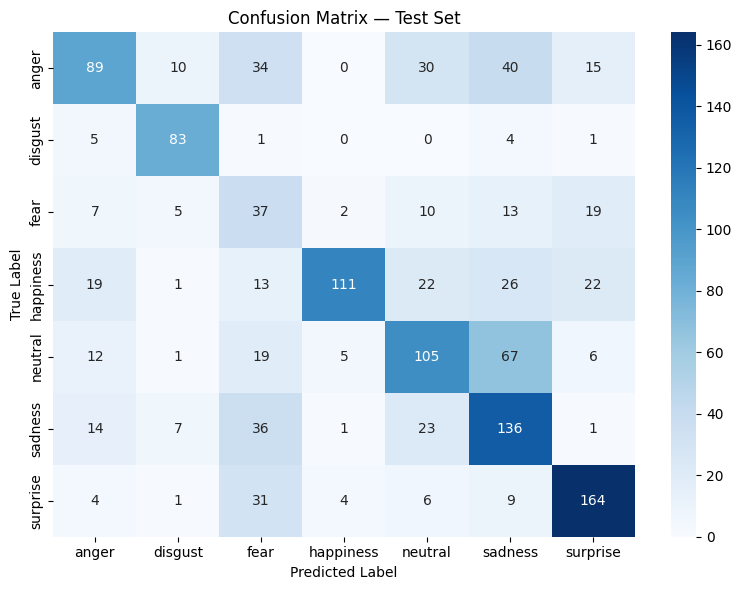

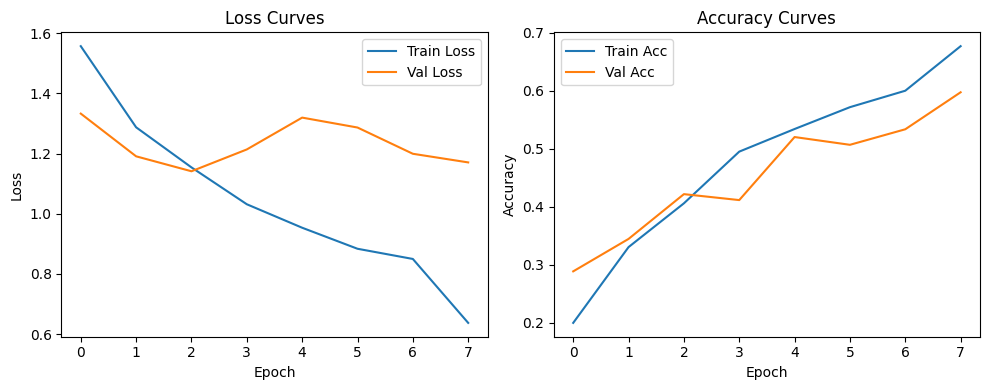


✅ Evaluation ολοκληρώθηκε!


In [ ]:
# ============================================================
# ΒΗΜΑ 11: Evaluation στο Test Set
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

IDX_TO_EMOTION = {v: k for k, v in EMOTION_TO_IDX.items()}

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for imgs, texts, labels in test_loader:
        imgs   = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs)
        preds   = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

target_names = [IDX_TO_EMOTION[i] for i in range(NUM_CLASSES)]
print("📊 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=target_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs,   label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves')
plt.legend()

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

print("\n✅ Evaluation ολοκληρώθηκε!")

In [ ]:
# ============================================================
# ΒΗΜΑ 12: Gradio Application με Συμβουλές
# ============================================================

!pip install gradio -q

import gradio as gr
import torch
import clip
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

IDX_TO_EMOTION = {
    0: 'anger',
    1: 'disgust',
    2: 'fear',
    3: 'happiness',
    4: 'neutral',
    5: 'sadness',
    6: 'surprise'
}

# Feedback + Συμβουλές ανά emotion
EMOTION_INFO = {
    'happiness': {
        'feedback': "Your facial expression and description both reflect happiness. This coherence suggests a genuine positive emotional state.",
        'tip': "💡 **Tip:** Savour this moment — sharing positive experiences with others can amplify and sustain feelings of happiness."
    },
    'sadness': {
        'feedback': "Both signals reflect sadness. Acknowledging this feeling is an important step toward emotional awareness.",
        'tip': "💡 **Tip:** Allow yourself to feel this emotion without judgment. Gentle activities like journaling, a short walk, or talking to someone you trust can help."
    },
    'anger': {
        'feedback': "Your expression and description both convey anger. This may indicate a situation that feels unfair or threatening.",
        'tip': "💡 **Tip:** Before responding, try taking slow deep breaths or stepping away briefly. Physical movement can also help discharge anger constructively."
    },
    'fear': {
        'feedback': "Both signals suggest fear or anxiety. This may reflect uncertainty or anticipation of a difficult situation.",
        'tip': "💡 **Tip:** Try grounding yourself by focusing on 5 things you can see, 4 you can touch, 3 you can hear. This can help reduce anxiety in the moment."
    },
    'disgust': {
        'feedback': "Both signals indicate disgust. This emotion often signals a boundary violation or something that conflicts with your values.",
        'tip': "💡 **Tip:** Try to identify the specific source of this feeling. Setting clear boundaries around situations that trigger disgust can be empowering."
    },
    'neutral': {
        'feedback': "Your expression and description appear calm and balanced.",
        'tip': "💡 **Tip:** A neutral state is a good opportunity for reflection or mindful awareness of your surroundings and inner state."
    },
    'surprise': {
        'feedback': "Both signals reflect surprise, suggesting an unexpected event has occurred.",
        'tip': "💡 **Tip:** Give yourself a moment to process the unexpected. Surprise can be positive or negative — identifying which can help you decide how to respond."
    },
}

MISMATCH_TIPS = {
    ('sadness', 'fear'):     "💡 **Tip:** When sadness and anxiety overlap, it can help to separate the two feelings — what specifically are you sad about, and what are you afraid of?",
    ('anger', 'sadness'):    "💡 **Tip:** Anger and sadness often co-exist. Sometimes anger is a protective response to underlying hurt. Journaling may help clarify what you're truly feeling.",
    ('fear', 'sadness'):     "💡 **Tip:** Fear and sadness together can feel overwhelming. Focus on one small, manageable step you can take right now.",
    ('happiness', 'neutral'):"💡 **Tip:** Your expression seems positive but your words are neutral. It's okay to not fully express how you feel — take a moment to check in with yourself.",
    ('neutral', 'sadness'):  "💡 **Tip:** Sometimes we mask sadness with a neutral expression. Be gentle with yourself and allow space to process your feelings.",
}

def get_feedback(visual_emotion, text_emotion, visual_probs):
    top2_idx = np.argsort(visual_probs)[::-1][:2]
    top2     = [(IDX_TO_EMOTION[i], round(float(visual_probs[i])*100, 1)) for i in top2_idx]

    if visual_emotion == text_emotion:
        alignment = "✅ **Aligned:** Your facial expression matches your description."
        base_fb   = EMOTION_INFO.get(visual_emotion, {}).get('feedback', '')
        tip       = EMOTION_INFO.get(visual_emotion, {}).get('tip', '')
    else:
        alignment = "⚠️ **Misaligned:** Your facial expression differs from your description."
        v_word    = visual_emotion
        t_word    = text_emotion
        base_fb   = (f"Your facial expression suggests **{v_word}**, while your description "
                     f"reflects **{t_word}**. This may indicate a complex emotional state "
                     f"where your outward expression differs from your inner experience.")
        tip = MISMATCH_TIPS.get(
            (visual_emotion, text_emotion),
            f"💡 **Tip:** When your expression and feelings differ, it can be helpful to pause and reflect on which emotion feels more present for you right now."
        )

    feedback = f"""
## Emotion Analysis

{alignment}

**Visual Emotion:** {visual_emotion.capitalize()} ({top2[0][1]}%)
**Text Emotion:** {text_emotion.capitalize()}

**Top emotions detected:**
- {top2[0][0].capitalize()}: {top2[0][1]}%
- {top2[1][0].capitalize()}: {top2[1][1]}%

---

### 💭 Reflective Feedback
{base_fb}

{tip}

---
*This system is designed as a reflective tool to support emotional awareness. It is not a clinical diagnostic tool.*
"""
    return feedback

inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def analyze_emotion(image, text_description):
    if image is None:
        return "⚠️ Please upload a facial image."
    if not text_description or len(text_description.strip()) < 3:
        return "⚠️ Please provide a text description of your emotional state."

    # --- Visual inference ---
    img        = Image.fromarray(image).convert('RGB')
    img_tensor = inference_transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        visual_output = model(img_tensor)
        visual_probs  = torch.softmax(visual_output, dim=1).squeeze().cpu().numpy()

    visual_emotion = IDX_TO_EMOTION[np.argmax(visual_probs)]

    # --- Text inference via CLIP zero-shot ---
    text_clean    = text_description.lower().strip()
    text_tokens   = clip.tokenize([text_clean], truncate=True).to(device)

    emotion_prompts = [f"a person feeling {em}" for em in IDX_TO_EMOTION.values()]
    prompt_tokens   = clip.tokenize(emotion_prompts, truncate=True).to(device)

    with torch.no_grad():
        text_emb   = clip_model.encode_text(text_tokens)
        text_emb   = text_emb / text_emb.norm(dim=-1, keepdim=True)
        prompt_emb = clip_model.encode_text(prompt_tokens)
        prompt_emb = prompt_emb / prompt_emb.norm(dim=-1, keepdim=True)
        text_scores = (text_emb @ prompt_emb.T).squeeze().cpu().numpy()

    text_emotion = IDX_TO_EMOTION[np.argmax(text_scores)]

    return get_feedback(visual_emotion, text_emotion, visual_probs)

# --- Gradio Interface ---
demo = gr.Interface(
    fn=analyze_emotion,
    inputs=[
        gr.Image(label="📷 Upload Facial Image"),
        gr.Textbox(
            label="💬 Describe your emotional state",
            placeholder="e.g., I feel really anxious about tomorrow's presentation...",
            lines=3
        )
    ],
    outputs=gr.Markdown(label="Emotion Analysis & Feedback"),
    title="Multimodal Emotion Recognition — Human-AI Collaborative System",
    description="""
    This system analyzes your emotional state by combining **facial expression recognition**
    with **linguistic emotion analysis**. Upload a facial image and describe how you feel
    to receive reflective feedback and personalized suggestions.

    *This is a research prototype. Not intended for clinical use.*
    """,
    theme=gr.themes.Soft()
)

# Αντί για share=True, χρησιμοποίησε inline
demo.launch(share=True, debug=True, show_error=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://e61036a08048b2440c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# --- Variant 3: Multimodal (late fusion) --- FIXED
multi_preds  = []
multi_labels = []

with torch.no_grad():
    for imgs, texts, labels in test_loader:
        imgs  = imgs.to(device)
        texts = texts.to(device)

        # Visual scores
        visual_out   = model(imgs)
        visual_probs = torch.softmax(visual_out, dim=1).cpu()  # → cpu

        # Text scores
        text_emb    = clip_model.encode_text(texts)
        text_emb    = text_emb / text_emb.norm(dim=-1, keepdim=True)
        text_scores = torch.softmax((text_emb @ prompt_emb.T), dim=1).cpu()  # → cpu

        # Late fusion
        combined = 0.6 * visual_probs + 0.4 * text_scores
        preds    = combined.argmax(dim=1)
        multi_preds.extend(preds.numpy())
        multi_labels.extend(labels.numpy())

multi_acc = accuracy_score(multi_labels, multi_preds)
multi_f1  = f1_score(multi_labels, multi_preds, average='macro')

print(f"\n📊 Multimodal (Late Fusion 0.6v + 0.4t):")
print(f"   Accuracy: {multi_acc:.3f}")
print(f"   Macro F1: {multi_f1:.3f}")

print(f"\n{'='*45}")
print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10}")
print(f"{'='*45}")
print(f"{'Visual Only (ResNet-50)':<25} {visual_acc:>10.3f} {visual_f1:>10.3f}")
print(f"{'Text Only (CLIP)':<25} {text_acc:>10.3f} {text_f1:>10.3f}")
print(f"{'Multimodal (Late Fusion)':<25} {multi_acc:>10.3f} {multi_f1:>10.3f}")
print(f"{'='*45}")


📊 Multimodal (Late Fusion 0.6v + 0.4t):
   Accuracy: 0.570
   Macro F1: 0.574

Model                       Accuracy   Macro F1
Visual Only (ResNet-50)        0.570      0.574
Text Only (CLIP)               0.238      0.173
Multimodal (Late Fusion)       0.570      0.574
